# Multi-burner hot-oil heater and CO-emissions diagnostics

This notebook demonstrates the native NeqSim `MultiBurnerFiredHeater` with an optional Cantera 3.2.0 finite-rate backend. It keeps two experiments separate:

1. seven versus five active burners at equal total fuel and common-air supply; and
2. a fuel-load sweep at fixed common-air flow with an explicitly assumed local-air capture curve.

The example reports actual CO mass rate, dry concentration, 3 vol% O2-corrected concentration, oxygen, burner and stack temperatures, useful hot-oil heat, residual chemical power, methane, organic-carbon diagnostics, projection omissions, and energy/conservation checks.

> **Scope:** GRI-Mech 3.0 is used only as a software and physics demonstration. The model is not calibrated to plant measurements and does not qualify C3/C4 chemistry, spatial geometry, emissions compliance, burner safety, or heater design.


## Reproducible setup

The clean-runtime path pins NeqSim commit `64e0a0a5997c0d130b9326a78d46269063f5bc94`, builds its Java classes, and verifies that `MultiBurnerFiredHeater` is loaded from that build. Local validation may supply an audited source directory and classpath through `NEQSIM_SOURCE_ROOT` and `NEQSIM_LOCAL_CLASSPATH`; the saved numerical outputs below were produced from connector-reconstructed source at the same commit plus NeqSim 3.23.0 dependencies.


In [1]:
import hashlib
import json
import os
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

NEQSIM_SOURCE_REF = "64e0a0a5997c0d130b9326a78d46269063f5bc94"
PINNED_NEQSIM_SHA = NEQSIM_SOURCE_REF
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")
PINNED_NEQSIM_VERSION = "3.23.0"
PINNED_CANTERA_VERSION = "3.2.0"

local_source = os.environ.get("NEQSIM_SOURCE_ROOT")
local_classpath = os.environ.get("NEQSIM_LOCAL_CLASSPATH")

if local_source and local_classpath:
    source_root = Path(local_source).resolve()
    classpath = local_classpath.split(os.pathsep)
    resolved_source_ref = NEQSIM_SOURCE_REF
    setup_mode = "audited connector source with compiled master overlay"
else:
    source_root = Path("/content/neqsim-source")
    if source_root.exists():
        subprocess.run(["rm", "-rf", str(source_root)], check=True)
    subprocess.run(
        [
            "git",
            "clone",
            "--filter=blob:none",
            "https://github.com/equinor/neqsim.git",
            str(source_root),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_REF],
        cwd=source_root,
        check=True,
    )
    resolved_source_ref = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=source_root,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    assert resolved_source_ref == NEQSIM_SOURCE_REF
    classpath_file = source_root / "target" / "heater-classpath.txt"
    subprocess.run(
        [
            "./mvnw",
            "-B",
            "-ntp",
            "-DskipTests",
            "compile",
            "dependency:build-classpath",
            f"-Dmdep.outputFile={classpath_file}",
        ],
        cwd=source_root,
        check=True,
    )
    dependencies = classpath_file.read_text(encoding="utf-8").strip().split(os.pathsep)
    classpath = [str(source_root / "target" / "classes")] + dependencies
    setup_mode = "clean pinned source build"

combustion_examples = source_root / "examples" / "combustion"
sys.path.insert(0, str(combustion_examples))

from cantera_backend import CanteraBackend
from multi_burner_fired_heater import (
    build_case,
    initialize_runtime,
    run_demonstration,
    run_with_diagnostics,
    summarize,
)

import jpype

for classpath_entry in classpath:
    jpype.addClassPath(classpath_entry)

JavaType = initialize_runtime(source_root, classpath)
heater_class = JavaType("neqsim.process.equipment.reactor.MultiBurnerFiredHeater")
class_origin = str(
    heater_class.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert "target/classes" in class_origin or "overlay-classes" in class_origin
backend = CanteraBackend("gri30.yaml")

print(f"Setup mode: {setup_mode}")
print(f"Pinned NeqSim commit: {resolved_source_ref}")
print(f"NeqSim dependency baseline: {PINNED_NEQSIM_VERSION}")
print(f"Cantera: {PINNED_CANTERA_VERSION}")
print(f"Loaded Java class: {heater_class.class_.getName()}")
print(f"Loaded class origin: {class_origin}")


Setup mode: audited connector source with compiled master overlay
Pinned NeqSim commit: 64e0a0a5997c0d130b9326a78d46269063f5bc94
NeqSim dependency baseline: 3.23.0
Cantera: 3.2.0
Loaded Java class: neqsim.process.equipment.reactor.MultiBurnerFiredHeater
Loaded class origin: file:/workspace/scratch/ce81b797f3da/overlay-classes/


## Execute the declared experiments

The 30 MW reference case uses a 50/50 molar ethane/propane fuel, common air, seven installed burners, a separate n-decane hot-oil stream, grey radiation plus convection to the tubes, and steady refractory loss. The load sweep keeps the common-air stream fixed. Its local-air capture fraction is an illustrative assumption, not a geometry-derived correlation or fitted emissions factor.


In [2]:
results = run_demonstration(
    JavaType,
    backend,
    include_sweep=True,
    sweep_projection_tolerance=1.0e-3,
)

scale_results = []
for firing_mw in (10.0, 20.0, 30.0, 40.0):
    process, heater, fuel, air, oil, fuel_mass = build_case(
        JavaType,
        backend,
        firing_mw,
    )
    run_with_diagnostics(process, heater)
    row = summarize(heater)
    row["nominalFiringMW"] = firing_mw
    scale_results.append(row)

results["explicit_geometry_heat_transfer_scaling"] = scale_results
print("Completed seven/five burners, six load points, and four scale points.")


Completed seven/five burners, six load points, and four scale points.


## Seven versus five active burners

Total fuel and total common-air supply are unchanged. Therefore this comparison isolates the reduced network's burner-zone loading effect; it is not a claim about air leakage through closed burner ports.


In [3]:
burner_cases = {
    "Seven active": results["seven_burners"],
    "Five active": results["five_burners_same_total_fuel_air"],
}

burner_rows = []
for label, case in burner_cases.items():
    burner_rows.append(
        {
            "case": label,
            "CO kg/h": case["coMassRateKgPerHour"],
            "CO dry ppmv": case["coPpmvDry"],
            "CO dry mg/Nm3": case["coMgPerNormalM3DryAt273_15K101325Pa"],
            "CO at 3% O2 mg/Nm3": case["coMgPerNormalM3DryAtReferenceOxygen"],
            "Dry O2 vol%": case["oxygenDryVolPercent"],
            "Minimum burner K": case["minimumBurnerTemperatureK"],
            "Stack K": case["temperatureK"],
            "Useful oil heat MW": case["usefulHeatToOilW"] / 1.0e6,
            "Residual chemical MW": case["residualChemicalPowerW"] / 1.0e6,
            "CH4 dry mg/Nm3": case["methaneMgPerNormalM3Dry"],
            "Organic C mgC/Nm3": case["organicCarbonMgCPerNormalM3Dry"],
        }
    )

burner_table = pd.DataFrame(burner_rows).set_index("case")
display(burner_table.style.format("{:.6g}"))


,CO kg/h,CO dry ppmv,CO dry mg/Nm3,CO at 3% O2 mg/Nm3,Dry O2 vol%,Minimum burner K,Stack K,Useful oil heat MW,Residual chemical MW,CH4 dry mg/Nm3,Organic C mgC/Nm3
case,,,,,,,,,,,
Seven active,0.110188,3.05119,3.81297,3.66102,2.25705,2109.63,574.289,26.2714,0.0138193,3.07542e-16,2.40322e-08
Five active,0.103241,2.85881,3.57256,3.43076,2.26017,2094.83,574.294,26.2733,0.0117943,0,2.45311e-08


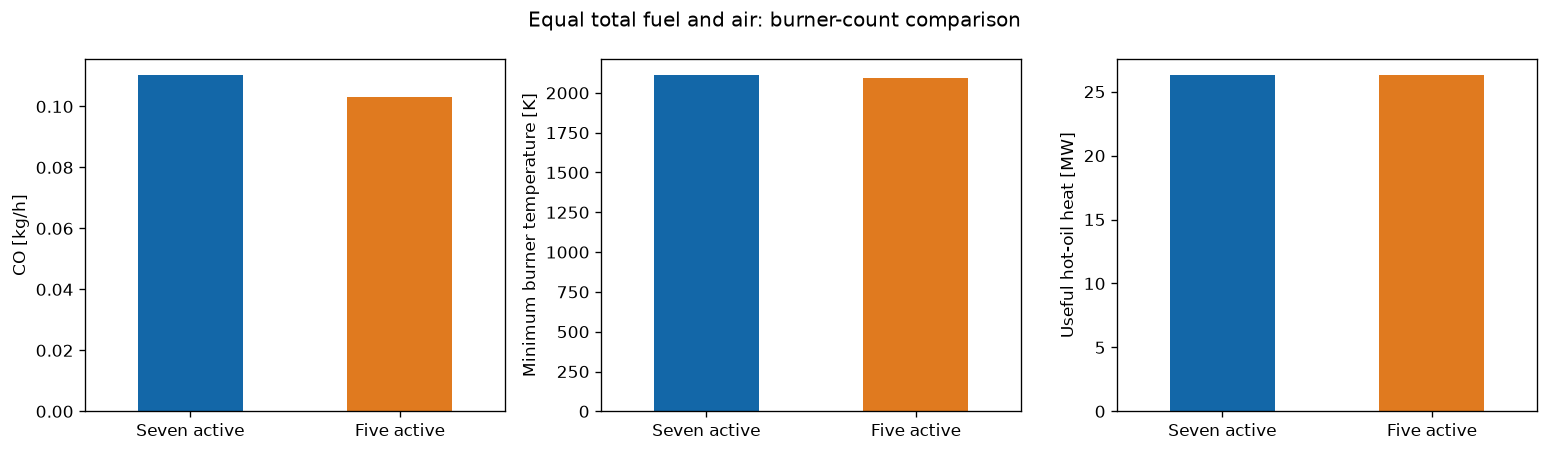

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
burner_table["CO kg/h"].plot.bar(ax=axes[0], color=["#1367a8", "#e07a1f"])
axes[0].set_ylabel("CO [kg/h]")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

burner_table["Minimum burner K"].plot.bar(
    ax=axes[1],
    color=["#1367a8", "#e07a1f"],
)
axes[1].set_ylabel("Minimum burner temperature [K]")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

burner_table["Useful oil heat MW"].plot.bar(
    ax=axes[2],
    color=["#1367a8", "#e07a1f"],
)
axes[2].set_ylabel("Useful hot-oil heat [MW]")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=0)

figure.suptitle("Equal total fuel and air: burner-count comparison")
figure.tight_layout()
plt.show()


## Fixed-common-air fuel-load sweep

Raw dry concentration and 3 vol% O2-corrected concentration are shown separately from actual CO mass rate. This prevents dilution or oxygen correction from being mistaken for a reduction in emitted CO mass.


In [5]:
sweep_rows = []
for case in results["constant_air_optional_entrainment_hypothesis"]:
    sweep_rows.append(
        {
            "Fuel load fraction": case["fuelLoadFraction"],
            "Captured air fraction": case["assumedCapturedAirFraction"],
            "CO kg/h": case["coMassRateKgPerHour"],
            "CO dry ppmv": case["coPpmvDry"],
            "CO dry mg/Nm3": case["coMgPerNormalM3DryAt273_15K101325Pa"],
            "CO at 3% O2 mg/Nm3": case["coMgPerNormalM3DryAtReferenceOxygen"],
            "Dry O2 vol%": case["oxygenDryVolPercent"],
            "Minimum burner K": case["minimumBurnerTemperatureK"],
            "Stack K": case["temperatureK"],
            "Useful oil heat MW": case["usefulHeatToOilW"] / 1.0e6,
            "Residual chemical MW": case["residualChemicalPowerW"] / 1.0e6,
            "CH4 dry mg/Nm3": case["methaneMgPerNormalM3Dry"],
            "Organic C mgC/Nm3": case["organicCarbonMgCPerNormalM3Dry"],
            "Diagnostic": case["branchDiagnostic"],
        }
    )

sweep_table = pd.DataFrame(sweep_rows).sort_values("Fuel load fraction")
display(sweep_table.style.format(precision=6))


,Fuel load fraction,Captured air fraction,CO kg/h,CO dry ppmv,CO dry mg/Nm3,CO at 3% O2 mg/Nm3,Dry O2 vol%,Minimum burner K,Stack K,Useful oil heat MW,Residual chemical MW,CH4 dry mg/Nm3,Organic C mgC/Nm3,Diagnostic
5,0.100000,0.180000,2.959195,76.151024,95.163428,1045.900275,19.271331,1502.913696,549.518247,0.045568,0.010689,0.038363,3.203230,BURNING
4,0.200000,0.360000,9.474704,245.719360,307.067396,1622.035289,17.511352,1499.636315,551.158370,2.955600,0.032223,0.110977,7.360326,INCOMPLETE_CONVERSION_OR_NO_USEFUL_HEAT
3,0.300000,0.540000,18.071874,472.360224,590.293024,2041.606497,15.724544,1496.978584,553.061544,5.859476,0.056032,0.171499,5.599184,INCOMPLETE_CONVERSION_OR_NO_USEFUL_HEAT
2,0.400000,0.720000,7.754922,204.364401,255.387466,651.778391,13.886212,1494.651075,555.279995,8.816740,0.021918,0.000004,0.033677,BURNING
1,0.600000,1.000000,0.033054,0.885391,1.106444,1.840177,10.137255,1569.409941,560.506104,14.672404,0.000254,0.000000,0.003879,BURNING
0,1.000000,1.000000,0.110188,3.051188,3.812970,3.661017,2.257051,2109.632083,574.288547,26.271354,0.013819,0.000000,0.000000,BURNING


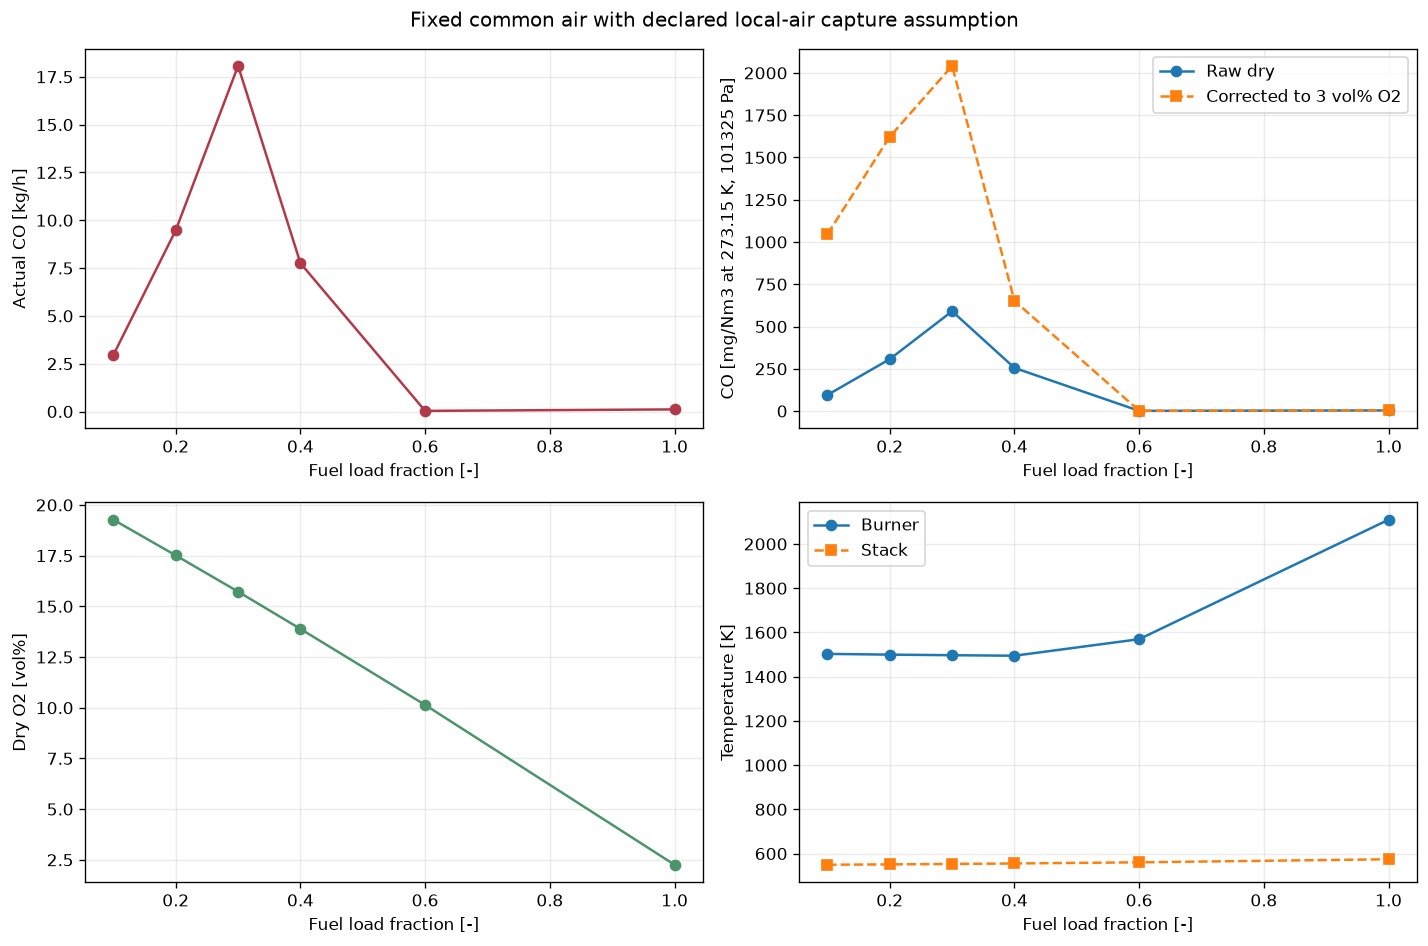

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
x = sweep_table["Fuel load fraction"]

axes[0, 0].plot(x, sweep_table["CO kg/h"], "o-", color="#b23a48")
axes[0, 0].set_ylabel("Actual CO [kg/h]")

axes[0, 1].plot(x, sweep_table["CO dry mg/Nm3"], "o-", label="Raw dry")
axes[0, 1].plot(
    x,
    sweep_table["CO at 3% O2 mg/Nm3"],
    "s--",
    label="Corrected to 3 vol% O2",
)
axes[0, 1].set_ylabel("CO [mg/Nm3 at 273.15 K, 101325 Pa]")
axes[0, 1].legend()

axes[1, 0].plot(x, sweep_table["Dry O2 vol%"], "o-", color="#4c956c")
axes[1, 0].set_ylabel("Dry O2 [vol%]")

axes[1, 1].plot(x, sweep_table["Minimum burner K"], "o-", label="Burner")
axes[1, 1].plot(x, sweep_table["Stack K"], "s--", label="Stack")
axes[1, 1].set_ylabel("Temperature [K]")
axes[1, 1].legend()

for axis in axes.flat:
    axis.set_xlabel("Fuel load fraction [-]")
    axis.grid(alpha=0.25)

figure.suptitle("Fixed common air with declared local-air capture assumption")
figure.tight_layout()
plt.show()


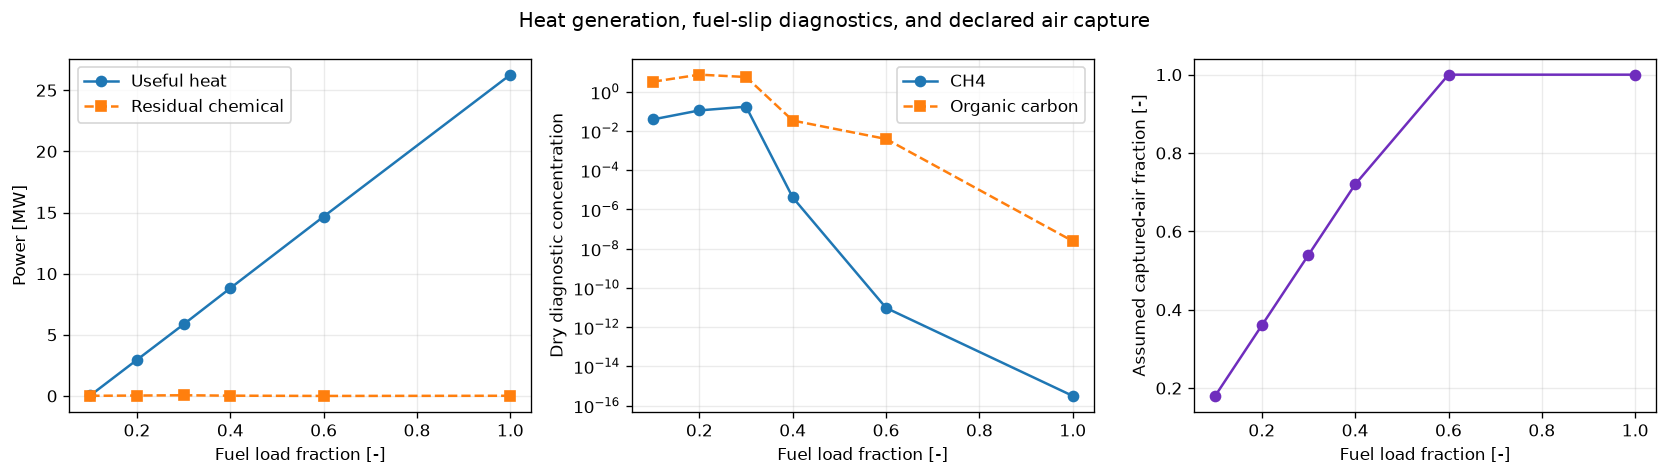

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x, sweep_table["Useful oil heat MW"], "o-", label="Useful heat")
axes[0].plot(x, sweep_table["Residual chemical MW"], "s--", label="Residual chemical")
axes[0].set_ylabel("Power [MW]")
axes[0].legend()

axes[1].semilogy(x, sweep_table["CH4 dry mg/Nm3"], "o-", label="CH4")
axes[1].semilogy(x, sweep_table["Organic C mgC/Nm3"], "s--", label="Organic carbon")
axes[1].set_ylabel("Dry diagnostic concentration")
axes[1].legend()

axes[2].plot(x, sweep_table["Captured air fraction"], "o-", color="#6f2dbd")
axes[2].set_ylabel("Assumed captured-air fraction [-]")

for axis in axes:
    axis.set_xlabel("Fuel load fraction [-]")
    axis.grid(alpha=0.25)

figure.suptitle("Heat generation, fuel-slip diagnostics, and declared air capture")
figure.tight_layout()
plt.show()


## Explicit 10–40 MW scaling

Reactive volumes and heat-transfer area scale explicitly with firing rate. This is a numerical and energy-balance sensitivity, not a scale-up qualification from a laboratory flame.


,Firing MW,CO kg/h,Stack K,Useful oil heat MW,Energy residual
0,10.00000000,0.03682193,573.94804155,8.74543506,-0.00000005
1,20.00000000,0.07351927,574.17702183,17.50658618,-0.00000005
2,30.00000000,0.11018808,574.28854711,26.27135433,-0.00000005
3,40.00000000,0.14684095,574.35906811,35.03814414,-0.00000005


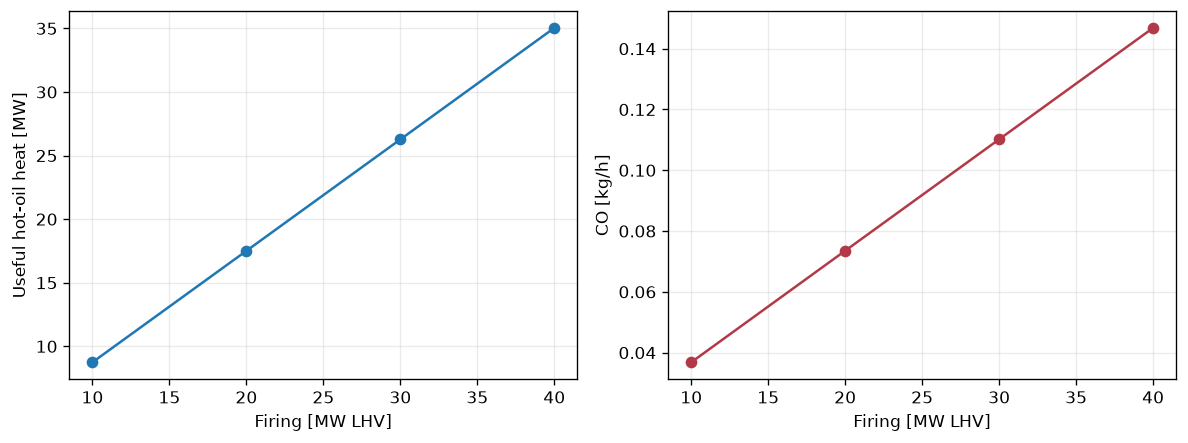

In [8]:
scale_rows = []
for case in results["explicit_geometry_heat_transfer_scaling"]:
    scale_rows.append(
        {
            "Firing MW": case["nominalFiringMW"],
            "CO kg/h": case["coMassRateKgPerHour"],
            "Stack K": case["temperatureK"],
            "Useful oil heat MW": case["usefulHeatToOilW"] / 1.0e6,
            "Energy residual": case["fullEnergyBalanceRelativeResidual"],
        }
    )

scale_table = pd.DataFrame(scale_rows)
display(scale_table.style.format(precision=8))

figure, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(scale_table["Firing MW"], scale_table["Useful oil heat MW"], "o-")
axes[0].set_xlabel("Firing [MW LHV]")
axes[0].set_ylabel("Useful hot-oil heat [MW]")
axes[1].plot(scale_table["Firing MW"], scale_table["CO kg/h"], "o-", color="#b23a48")
axes[1].set_xlabel("Firing [MW LHV]")
axes[1].set_ylabel("CO [kg/h]")
for axis in axes:
    axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()


## Conservation, projection, and provenance evidence

The native default projection tolerance is $10^{-6}$ for the seven/five cases. The optional load sweep declares $10^{-3}$ because frozen trace intermediates grow at lower load; the exact mechanism state remains available and no missing atoms are renormalized. Every reactor-zone mass and element balance is checked independently.


In [9]:
def maximum_zone_residual(case):
    maximum_mass = 0.0
    maximum_element = 0.0
    for zone in case["zoneConservationDiagnostics"]:
        maximum_mass = max(maximum_mass, abs(zone["massBalanceRelativeResidual"]))
        for element in zone["elementBalances"].values():
            value = element["acceptanceScaledResidual"]
            maximum_element = max(maximum_element, abs(value))
    return maximum_mass, maximum_element

validation_rows = []
for label, case in burner_cases.items():
    maximum_mass, maximum_element = maximum_zone_residual(case)
    validation_rows.append(
        {
            "case": label,
            "max zone mass residual": maximum_mass,
            "max zone element residual": maximum_element,
            "full energy residual": abs(case["fullEnergyBalanceRelativeResidual"]),
            "omitted C fraction": case["omittedElementFractions"]["C"],
            "omitted H fraction": case["omittedElementFractions"]["H"],
            "omitted O fraction": case["omittedElementFractions"]["O"],
            "omitted N fraction": case["omittedElementFractions"]["N"],
        }
    )

validation_table = pd.DataFrame(validation_rows).set_index("case")
display(validation_table.style.format("{:.3e}"))

assert validation_table["max zone mass residual"].max() < 1.0e-7
assert validation_table["max zone element residual"].max() < 1.0e-7
assert validation_table["full energy residual"].max() < 1.0e-6
assert validation_table[[
    "omitted C fraction",
    "omitted H fraction",
    "omitted O fraction",
    "omitted N fraction",
]].to_numpy().max() < 1.0e-6
print("Seven/five conservation, energy, and default projection gates passed.")


Seven/five conservation, energy, and default projection gates passed.


,max zone mass residual,max zone element residual,full energy residual,omitted C fraction,omitted H fraction,omitted O fraction,omitted N fraction
case,,,,,,,
Seven active,5.228e-10,5.228e-10,5.451e-08,3.719e-13,8.722e-07,6.466e-07,3.769e-11
Five active,3.588e-13,3.600e-13,5.454e-08,3.795e-13,8.624e-07,6.393e-07,2.962e-11


In [10]:
sweep_cases = results["constant_air_optional_entrainment_hypothesis"]
maximum_sweep_omission = max(
    max(case["omittedElementFractions"].values())
    for case in sweep_cases
)
maximum_sweep_energy_residual = max(
    abs(case["fullEnergyBalanceRelativeResidual"])
    for case in sweep_cases
)
co_by_load = {
    case["fuelLoadFraction"]: case["coMassRateKgPerHour"]
    for case in sweep_cases
}
useful_heat_by_load = {
    case["fuelLoadFraction"]: case["usefulHeatToOilW"]
    for case in sweep_cases
}

assert maximum_sweep_omission < 1.0e-3
assert maximum_sweep_energy_residual < 1.0e-6
assert co_by_load[0.3] > co_by_load[0.4]
assert co_by_load[0.2] < co_by_load[0.3]
assert useful_heat_by_load[0.3] > 0.0
assert useful_heat_by_load[0.2] > 0.0

print(f"Maximum sweep omitted-element fraction: {maximum_sweep_omission:.6e}")
print(f"Maximum sweep energy residual: {maximum_sweep_energy_residual:.6e}")
print("Rise/fall CO response occurs with positive useful heat at 30% and 20% load.")


Maximum sweep omitted-element fraction: 3.247241e-04
Maximum sweep energy residual: 1.788856e-07
Rise/fall CO response occurs with positive useful heat at 30% and 20% load.


In [11]:
seven = results["seven_burners"]
hydrogen_diagnostics = seven["elementProjectionDiagnostics"]["H"]
omitted_hydrogen = hydrogen_diagnostics["omittedSpeciesMolAtomsPerSecond"]
top_omitted = sorted(
    omitted_hydrogen.items(),
    key=lambda item: item[1],
    reverse=True,
)[:8]
omitted_table = pd.DataFrame(
    top_omitted,
    columns=["Mechanism species", "Omitted H atom mol/s"],
)
display(omitted_table.style.format({"Omitted H atom mol/s": "{:.6e}"}))

provenance = seven["provenance"]
provenance_table = pd.DataFrame(
    {
        "item": [
            "Solver",
            "Solver version",
            "Mechanism",
            "Canonical mechanism SHA-256",
            "Species",
            "Reactions",
            "Qualification status",
        ],
        "value": [
            provenance["solver"],
            provenance["solverVersion"],
            provenance["mechanism"],
            provenance["resolvedMechanismSha256"],
            provenance["speciesCount"],
            provenance["reactionCount"],
            "Software demonstration only",
        ],
    }
)
display(provenance_table)


,Mechanism species,Omitted H atom mol/s
0,H2O2,7.911012e-05
1,OH,2.634008e-05
2,HNO,2.310688e-08
3,HO2,1.673490e-08
4,H,7.924073e-10
5,HNCO,1.594103e-11
6,NH2,3.732450e-12
7,HCN,6.806796e-14


,item,value
0,Solver,Cantera
1,Solver version,3.2.0
2,Mechanism,gri30.yaml
3,Canonical mechanism SHA-256,3cb2078af590038e2f9d3f33a8079ac882e6c1a4701c70...
4,Species,53
5,Reactions,325
6,Qualification status,Software demonstration only


## Interpretation and limits

- Seven and five active burners give similar total useful heat at equal total fuel and air, while the finite-rate zone loading changes CO slightly.
- The separate fixed-air sweep produces a CO rise and fall in both mass and concentration. This emerges from kinetics, local-air capture, residence volume, and heat transfer; no direct emissions factor or target curve is fitted.
- Positive useful oil heat persists through the high-CO 30% and 20% load points. Complete extinction is therefore not used to explain the response.
- Raw dry, reference-O2-corrected, and actual-mass results are all retained. Oxygen correction is not interpreted as physical CO destruction.
- CH4 and organic-carbon values are mechanism diagnostics, not VOC-instrument equivalents.
- The sweep's local-air capture relation, effective tube sink, chamber geometry, steady refractory, and GRI-Mech chemistry are assumptions. Spatial burner geometry and dynamic refractory storage are not resolved.
- Public C2 and extrapolative C1 comparisons exist in NeqSim, but licensed C3/C4 qualification data remain missing. Do not use this notebook for plant calibration, emissions compliance, safety certification, or heater design.
